##### Copyright 2026 Google LLC.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://ai.google.dev/gemma/docs/embeddinggemma/fine-tuning-multimodal-embeddinggemma-with-sentence-transformers"><img src="https://ai.google.dev/static/site-assets/images/docs/notebook-site-button.png" height="32" width="32" />View on ai.google.dev</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/google-gemma/cookbook/blob/main/docs/embeddinggemma/fine-tuning-multimodal-embeddinggemma-with-sentence-transformers.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/google-gemma/cookbook/blob/main/docs/embeddinggemma/fine-tuning-multimodal-embeddinggemma-with-sentence-transformers.ipynb"><img src="https://www.kaggle.com/static/images/logos/kaggle-logo-transparent-300.png" height="32" width="70"/>Run in Kaggle</a>
  </td>
  <td>
    <a target="_blank" href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fgoogle-gemma%2Fcookbook%2Fmain%2Fdocs%2Fembeddinggemma%2Ffine-tuning-multimodal-embeddinggemma-with-sentence-transformers.ipynb"><img src="https://ai.google.dev/images/cloud-icon.svg" width="40" />Open in Vertex AI</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/google-gemma/cookbook/blob/main/docs/embeddinggemma/fine-tuning-multimodal-embeddinggemma-with-sentence-transformers.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

# Fine-tune Multimodal Embeddings with EmbeddingGemma 2 and Sentence Transformers

**EmbeddingGemma 2** maps text, images, audio, and video into a unified 768-dimensional vector space. So you can fine-tune it on **cross-modal triplets**, such as `(text_query, positive_image, negative_image)`, using the same Sentence Transformers training pipeline used for text.

> **Note:** This guide requires a GPU which support bfloat16 data type such as NVIDIA L4 or NVIDIA A100.

### Example Scenario: Korean Ink Wash Painting Archive Search

Imagine you are building a digital archive search engine for a museum exhibition of traditional Joseon-dynasty Korean paintings:

* **[Shin Yunbok](https://artsandculture.google.com/entity/sin-yun-bok/m0749t2), *Dano Pungjeong* (Scenery on Dano Day)** (`ink-wash-1.png`): Genre painting (*pungsokhwa*) of women bathing by a stream and riding a swing during the Dano festival<br>![Shin Yunbok](https://github.com/bebechien/gemma/raw/refs/heads/main/images/ink-wash-1.png)
* **[Jeong Seon](https://artsandculture.google.com/entity/jeong-seon/m06w7x2), *Inwangjesaekdo* (Clearing after Rain on Mount Inwang)** (`ink-wash-2.png`): True-view landscape painting (*jingyeong sansuhwa*) of rain-soaked granite peaks emerging from mist<br>![Jeong Seon](https://github.com/bebechien/gemma/raw/refs/heads/main/images/ink-wash-2.png)
* **[Kim Hongdo](https://artsandculture.google.com/entity/gim-hongdo/m0749cz), *Seodang* (Village School)** (`ink-wash-3.png`): Genre painting of a village schoolmaster, a weeping student, and giggling classmates<br>![Kim Hongdo](https://github.com/bebechien/gemma/raw/refs/heads/main/images/ink-wash-3.png)

Out of the box, **EmbeddingGemma 2** can retrieve the right painting when given a **descriptive scene caption** (such as *"Scenery on Dano Day"* or *"Village School"*). However, when a user searches by **artist name** alone (e.g. *"Show me an ink wash painting of Shin Yunbok."*), a model sees three visually similar traditional Korean ink wash works and may misrank them without domain-specific artist attribution.

**What this guide covers:**

* Installing dependencies and loading **EmbeddingGemma 2** (`google/embeddinggemma-2`) with text and vision encoders
* Evaluating baseline **text-to-image** retrieval performance (comparing artist-based queries vs. descriptive scene queries) before fine-tuning
* Preparing cross-modal `(anchor, positive, negative)` training triplets linking artist names to their paintings
* Fine-tuning the model using `SentenceTransformerTrainer`, `MultipleNegativesRankingLoss`, and column-specific task prompts
* Evaluating post-training improvements and saving your adapted multimodal model

> **New to multimodal inference with EmbeddingGemma 2?** See [Multimodal Embeddings with EmbeddingGemma 2](https://ai.google.dev/gemma/docs/embeddinggemma/multimodal-embeddinggemma-with-sentence-transformers) for an overview of image, audio, video, and interleaved inputs.

## Setup and Installation

Install `sentence-transformers`, `transformers`, `datasets`, and the multimedia libraries (`pillow`, `soundfile`, `torchcodec`) required for processing images, audio, and video.

Sentence Transformers is a Python framework for using and training embedding and reranker models. For more details on the framework, see the [Sentence Transformers documentation](https://www.sbert.net/).

In [ ]:
!pip install -U sentence-transformers transformers datasets pillow soundfile torchcodec

## (Optional) Hugging Face Authentication

You need a valid Hugging Face Token to publish your model. If you are running inside Google Colab, you can securely load your Hugging Face Token from Colab secrets; otherwise you can pass the token directly to `login()`. Make sure your token has write access if you plan to push your fine-tuned model to the Hub.

In [ ]:
# Login into Hugging Face Hub
from huggingface_hub import login
login()

## Load the Base Model

Load `google/embeddinggemma-2` using `SentenceTransformer`.

In [ ]:
from sentence_transformers import SentenceTransformer

model_id = "google/embeddinggemma-2"
model = SentenceTransformer(
    model_id,
    config_kwargs={"audio_config": None},
)

print(f"Device: {model.device}")
print(f"dtype: {model.dtype}")
print(model)
print("Total number of parameters in the model:", sum(p.numel() for p in model.parameters()))

Loading weights:   0%|          | 0/624 [00:00<?, ?it/s]

Device: cuda:0
dtype: torch.bfloat16
SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}, 'image': {'method': 'forward', 'method_output_name': 'last_hidden_state'}, 'audio': {'method': 'forward', 'method_output_name': 'last_hidden_state'}, 'video': {'method': 'forward', 'method_output_name': 'last_hidden_state'}, 'message': {'method': 'forward', 'method_output_name': 'last_hidden_state', 'format': 'structured'}}, 'module_output_name': 'token_embeddings', 'architecture': 'EmbeddingGemma2Model'})
  (1): Pooling({'embedding_dimension': 768, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
)
Total number of parameters in the model: 438760448


> **Tip:** Since this tutorial fine-tunes on **text and image** data, we pass `config_kwargs={"audio_config": None}` during initialization to omit the audio encoder and reduce GPU memory usage during training. If your fine-tuning dataset also includes audio, initialize `SentenceTransformer(model_id)` with default settings to load all modality encoders.

> **Note on Precision:** EmbeddingGemma 2 activations are incompatible with `float16`. Use `bfloat16` (default on supported GPUs) or `float32`.

## Baseline Evaluation (Before Fine-Tuning)

First, let's load the three Joseon-dynasty ink wash paintings and test how the base model ranks them when a visitor searches by artist name:
> *"Show me an ink wash painting of Shin Yunbok."*

Our three candidate paintings are:
1. **Shin Yunbok, *Dano Pungjeong* (Scenery on Dano Day)** (`ink-wash-1.png`) — **Target Match**
2. **Jeong Seon, *Inwangjesaekdo* (Clearing after Rain on Mount Inwang)** (`ink-wash-2.png`) — **Hard Negative**
3. **Kim Hongdo, *Seodang* (Village School)** (`ink-wash-3.png`) — **Hard Negative**

Shin Yunbok, Dano Pungjeong (Scenery on Dano Day)


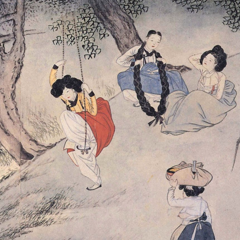

Jeong Seon, Inwangjesaekdo (Clearing after Rain on Mount Inwang)


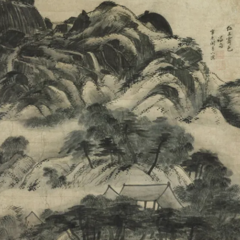

Kim Hongdo, Seodang (Village School)


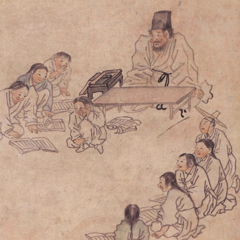

--------------------------------------------------------------------------------
Baseline Scores (Before Fine-Tuning):
Query: Show me an ink wash painting of Shin Yunbok.
Painting: Shin Yunbok, Dano Pungjeong (Scenery on Dano Day)                  -> 🤖 Score: 0.6753
Painting: Jeong Seon, Inwangjesaekdo (Clearing after Rain on Mount Inwang)   -> 🤖 Score: 0.7005
Painting: Kim Hongdo, Seodang (Village School)                               -> 🤖 Score: 0.6631


In [ ]:
from PIL import Image
from IPython.display import display
import requests

IMAGE_SIZE = 240

def load_image(url):
    return Image.open(requests.get(url, stream=True).raw).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))

# Load Korean ink wash paintings
ink_wash_1 = load_image("https://github.com/bebechien/gemma/raw/refs/heads/main/images/ink-wash-1.png")
ink_wash_2 = load_image("https://github.com/bebechien/gemma/raw/refs/heads/main/images/ink-wash-2.png")
ink_wash_3 = load_image("https://github.com/bebechien/gemma/raw/refs/heads/main/images/ink-wash-3.png")

task_name = "Retrieval-query"
query = "Show me an ink wash painting of Shin Yunbok."

candidates = [
    {"label": "Shin Yunbok, Dano Pungjeong (Scenery on Dano Day)", "image": ink_wash_1},
    {"label": "Jeong Seon, Inwangjesaekdo (Clearing after Rain on Mount Inwang)", "image": ink_wash_2},
    {"label": "Kim Hongdo, Seodang (Village School)", "image": ink_wash_3},
]

for item in candidates:
    print(item["label"])
    display(item["image"])

def evaluate_retrieval(query_text, candidate_items):
    print(f"Query: {query_text}")
    query_emb = model.encode(query_text, prompt_name=task_name)
    image_embs = model.encode([item["image"] for item in candidate_items])
    similarities = model.similarity(query_emb, image_embs)[0]

    for item, score in zip(candidate_items, similarities):
        print(f"Painting: {item['label']:<66} -> 🤖 Score: {score.item():.4f}")

print("-"*80)
print("Baseline Scores (Before Fine-Tuning):")
evaluate_retrieval(query, candidates)

> **Note on Task Prompts for Cross-Modal Search:** Task-specific prompt prefixes apply to **text inputs only**. Here we encode the text query with `prompt_name="Retrieval-query"` (`"task: search result | query: "`) and encode the candidate images directly without a text prefix. For details on all available prompts, see the [EmbeddingGemma 2 model card](https://ai.google.dev/gemma/docs/embeddinggemma/model_card_2#best_practices).

### Why Did the Baseline Query Misrank the Paintings?

In the baseline evaluation above, searching for *"Show me an ink wash painting of Shin Yunbok."* **misranks** the candidates: the base model assigns the highest similarity score to **Jeong Seon's  _Inwangjesaekdo_** instead of the true match, **Shin Yunbok's _Dano Pungjeong_**.

Note that the base model **does** retrieve the correct image out of the box when you provide a **descriptive caption** about the visual scene itself (such as *"Dano Pungjeong (Scenery on Dano Day)"* or *"Seodang (Village School)"* below). However, because an artist's name (*"Shin Yunbok"*) is domain metadata rather than a literal visual description of the scene, fine-tuning is needed to teach the model to associate each artist with their painting.

In [ ]:
query_desc = "Dano Pungjeong (Scenery on Dano Day)"
evaluate_retrieval(query_desc, candidates)

print("-"*80)
query_desc = "Seodang (Village School)"
evaluate_retrieval(query_desc, candidates)

Query: Dano Pungjeong (Scenery on Dano Day)
Painting: Shin Yunbok, Dano Pungjeong (Scenery on Dano Day)                  -> 🤖 Score: 0.6892
Painting: Jeong Seon, Inwangjesaekdo (Clearing after Rain on Mount Inwang)   -> 🤖 Score: 0.6767
Painting: Kim Hongdo, Seodang (Village School)                               -> 🤖 Score: 0.6478
--------------------------------------------------------------------------------
Query: Seodang (Village School)
Painting: Shin Yunbok, Dano Pungjeong (Scenery on Dano Day)                  -> 🤖 Score: 0.6777
Painting: Jeong Seon, Inwangjesaekdo (Clearing after Rain on Mount Inwang)   -> 🤖 Score: 0.6782
Painting: Kim Hongdo, Seodang (Village School)                               -> 🤖 Score: 0.6997


## Prepare the Multimodal Fine-Tuning Dataset

To teach the model to associate each Joseon-dynasty master with their artwork, we structure our training data as cross-modal contrastive triplets: **`(anchor, positive, negative)`**:

* **`anchor` (Text)**: The artist's name (`"Shin Yunbok"`, `"Jeong Seon"`, `"Kim Hongdo"`).
* **`positive` (Image)**: The matching `PIL.Image` painting by that artist.
* **`negative` (Image)**: Another traditional Korean ink wash painting by a different artist, acting as a visual hard negative.

`SentenceTransformerTrainer` automatically inspects each column's modality and preprocesses text and images transparently—no manual tokenization or pixel preprocessing is required.

In [ ]:
from datasets import Dataset

triplets = [
    [
        "Shin Yunbok",
        ink_wash_1,
        ink_wash_2,
    ],
    [
        "Jeong Seon",
        ink_wash_2,
        ink_wash_3,
    ],
    [
        "Kim Hongdo",
        ink_wash_3,
        ink_wash_1,
    ],
]

# Convert into a Hugging Face Dataset with text 'anchor' and image 'positive'/'negative' columns
data_as_dicts = [
    {"anchor": row[0], "positive": row[1], "negative": row[2]}
    for row in triplets
]
train_dataset = Dataset.from_list(data_as_dicts)
print(train_dataset)

Dataset({
    features: ['anchor', 'positive', 'negative'],
    num_rows: 3
})


> **Tip (Other Multimodal Formats):** Dataset columns can also contain image file paths/URLs, audio waveforms, video paths, or multimodal dictionaries like `{"text": "caption", "image": pil_image}` when training on interleaved inputs.

> **Note:** For demonstration purposes, we create a compact dataset of 3 cross-modal triplets below. In production applications, use hundreds or thousands of domain-specific pairs or triplets for robust generalization.

## Fine-Tuning the Multimodal Model

We fine-tune the model using `SentenceTransformerTrainer` and **`MultipleNegativesRankingLoss`**, which pulls `(anchor, positive)` text-image pairs closer together in the shared 768-dimensional embedding space while pushing `(anchor, negative)` pairs—and in-batch negatives—apart.

Crucially, because only the `anchor` column contains text while `positive` and `negative` contain images, we pass a **column-specific prompt mapping** `prompts={"anchor": model.prompts[task_name]}` in `SentenceTransformerTrainingArguments`. This ensures the task prefix is prepended only to text queries and not to image inputs.

In [ ]:
from sentence_transformers import (
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
)
from sentence_transformers.sentence_transformer.losses import MultipleNegativesRankingLoss
from transformers import TrainerCallback

# Initialize contrastive ranking loss
loss = MultipleNegativesRankingLoss(model)

# Configure training arguments
args = SentenceTransformerTrainingArguments(
    output_dir="my-multimodal-embeddinggemma-2",
    prompts={"anchor": model.prompts[task_name]},  # Apply task prompt prefix only to the text 'anchor' column
    num_train_epochs=5,
    per_device_train_batch_size=1,
    learning_rate=2e-5,
    bf16=True,                                     # EmbeddingGemma 2 uses bfloat16 (incompatible with fp16)
    fp16=False,
    logging_steps=train_dataset.num_rows,
    report_to="none",
)

class EvaluationCallback(TrainerCallback):
    """Callback that evaluates cross-modal retrieval scores at each logging step."""

    def __init__(self, eval_fn):
        self.eval_fn = eval_fn

    def on_log(self, args, state, control, **kwargs):
        print(f"\n--- Step {state.global_step} Evaluation ---")
        self.eval_fn()

trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    loss=loss,
    callbacks=[EvaluationCallback(lambda: evaluate_retrieval(query, candidates))],
)

trainer.train()

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
3,1.000404
6,0.602180
9,0.364761
12,0.281820
15,0.247832



--- Step 3 Evaluation ---
Query: Show me an ink wash painting of Shin Yunbok.
Painting: Shin Yunbok, Dano Pungjeong (Scenery on Dano Day)                  -> 🤖 Score: 0.7203
Painting: Jeong Seon, Inwangjesaekdo (Clearing after Rain on Mount Inwang)   -> 🤖 Score: 0.6359
Painting: Kim Hongdo, Seodang (Village School)                               -> 🤖 Score: 0.6785

--- Step 6 Evaluation ---
Query: Show me an ink wash painting of Shin Yunbok.
Painting: Shin Yunbok, Dano Pungjeong (Scenery on Dano Day)                  -> 🤖 Score: 0.7185
Painting: Jeong Seon, Inwangjesaekdo (Clearing after Rain on Mount Inwang)   -> 🤖 Score: 0.6257
Painting: Kim Hongdo, Seodang (Village School)                               -> 🤖 Score: 0.6610

--- Step 9 Evaluation ---
Query: Show me an ink wash painting of Shin Yunbok.
Painting: Shin Yunbok, Dano Pungjeong (Scenery on Dano Day)                  -> 🤖 Score: 0.7107
Painting: Jeong Seon, Inwangjesaekdo (Clearing after Rain on Mount Inwang)   -> 🤖 Score: 0.

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- Step 15 Evaluation ---
Query: Show me an ink wash painting of Shin Yunbok.
Painting: Shin Yunbok, Dano Pungjeong (Scenery on Dano Day)                  -> 🤖 Score: 0.7070
Painting: Jeong Seon, Inwangjesaekdo (Clearing after Rain on Mount Inwang)   -> 🤖 Score: 0.6126
Painting: Kim Hongdo, Seodang (Village School)                               -> 🤖 Score: 0.6522


TrainOutput(global_step=15, training_loss=0.49939937591552735, metrics={'train_runtime': 20.5693, 'train_samples_per_second': 0.729, 'train_steps_per_second': 0.729, 'total_flos': 0.0, 'train_loss': 0.49939937591552735, 'epoch': 5.0})

## Evaluation After Fine-Tuning

Let's run our test query once more on the fine-tuned model and compare the post-training cross-modal similarity scores against our baseline:

In [ ]:
print("Post-Training Scores (After Fine-Tuning):")
evaluate_retrieval(query, candidates)

Post-Training Scores (After Fine-Tuning):
Query: Show me an ink wash painting of Shin Yunbok.
Painting: Shin Yunbok, Dano Pungjeong (Scenery on Dano Day)                  -> 🤖 Score: 0.7070
Painting: Jeong Seon, Inwangjesaekdo (Clearing after Rain on Mount Inwang)   -> 🤖 Score: 0.6126
Painting: Kim Hongdo, Seodang (Village School)                               -> 🤖 Score: 0.6522


### What Changed After Fine-Tuning?

Before fine-tuning, all three Joseon-dynasty paintings shared a similar traditional Korean ink wash aesthetic, causing the base model to misrank **Jeong Seon's _Inwangjesaekdo_** above **Shin Yunbok's _Dano Pungjeong_** when queried for *"Show me an ink wash painting of Shin Yunbok."*

After just 5 epochs (15 steps) of contrastive fine-tuning on `(artist_name, positive_image, negative_image)` triplets:
* Even though the training anchors only contained artist names (`"Shin Yunbok"`, `"Jeong Seon"`, `"Kim Hongdo"`), the model generalizes to the natural-language query *"Show me an ink wash painting of Shin Yunbok."*
* **Shin Yunbok, *Dano Pungjeong* (Scenery on Dano Day)** (`ink-wash-1.png`) rises from Rank #2 to Rank #1, already claiming the top rank after the very first epoch (Step 3).
* The competing ink-wash hard negatives (**Jeong Seon** and **Kim Hongdo**) are pushed further apart in the shared 768-dimensional embedding space.

## Saving and Sharing Your Model

Save your fine-tuned multimodal model locally so it can be reloaded directly with `SentenceTransformer`:

In [ ]:
# Save locally
model.save_pretrained("my-multimodal-embeddinggemma-2-finetuned")

To share your adapted model with your team or deploy it from the Hugging Face Hub, use `push_to_hub`:

In [ ]:
# Optional: Push your fine-tuned model to the Hugging Face Hub
model.push_to_hub("my-multimodal-embeddinggemma-2-finetuned")

## Summary and Next Steps

You have learned how to fine-tune **EmbeddingGemma 2** for cross-modal **text-to-image retrieval** using multimodal triplets and `SentenceTransformerTrainer`.

Explore what more you can do with EmbeddingGemma 2:

* [Multimodal Embeddings with EmbeddingGemma 2](https://ai.google.dev/gemma/docs/embeddinggemma/multimodal-embeddinggemma-with-sentence-transformers)
* [Generating Embeddings with EmbeddingGemma 2 (Text, RAG, Classification & MRL)](https://ai.google.dev/gemma/docs/embeddinggemma/inference-embeddinggemma-with-sentence-transformers)
* [Fine-tune EmbeddingGemma 2 with Sentence Transformers (Text)](https://ai.google.dev/gemma/docs/embeddinggemma/fine-tuning-embeddinggemma-with-sentence-transformers)
* [Sentence Transformers Multimodal Training Documentation](https://sbert.net/examples/sentence_transformer/training/multimodal/README.html)